In [37]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

import json


In [21]:
# task 1
df = pd.read_csv('pzz_fleet_data_full.csv')

In [22]:
# 1 (a)

cols = ['temperature', 'vibration', 'speed', 'fuel_consumption', 'load']

# 1. IQR Method
Q1, Q3 = df[cols].quantile(0.25), df[cols].quantile(0.75)
mask_iqr = ((df[cols] < (Q1 - 1.5 * (Q3 - Q1))) | (df[cols] > (Q3 + 1.5 * (Q3 - Q1)))).any(axis=1)

# 2. Z-score Method
mask_z = (np.abs(zscore(df[cols])) > 3).any(axis=1)

# 3. Isolation Forest
mask_if = IsolationForest(contamination=0.03, random_state=42).fit_predict(df[cols]) == -1


print(f"Counts -> IQR: {mask_iqr.sum()}, Z-score: {mask_z.sum()}, IF: {mask_if.sum()}")
print(f"Common to all: {(mask_iqr & mask_z & mask_if).sum()}")

Counts -> IQR: 484, Z-score: 210, IF: 300
Common to all: 210


In [23]:
with open('pzz_fleet_physical_limits.json', 'r') as f:
    limits = json.load(f)
print(limits)

{'temperature': [0, 200], 'vibration': [0, 100], 'speed': [0, 150], 'fuel_consumption': [0, 100], 'load': [0, 100]}


In [24]:
# 1 (b)

# Limits definition
limits = {'temperature': [0, 200], 'vibration': [0, 100], 'speed': [0, 150],
          'fuel_consumption': [0, 100], 'load': [0, 100]}

# 1. Identify Sensor Errors (Physically impossible)
mask_phys_err = pd.Series(False, index=df.index)
for col, (min_val, max_val) in limits.items():
    mask_phys_err |= (df[col] < min_val) | (df[col] > max_val)

# 2. Identify True Anomalies (Detected outliers that are physically possible)
# Using mask_if (Isolation Forest) as the main detector from (a)
mask_true_anomaly = mask_if & (~mask_phys_err)

# Assign categories
df['detected_class'] = 'normal'
df.loc[mask_true_anomaly, 'detected_class'] = 'anomaly'
df.loc[mask_phys_err, 'detected_class'] = 'error'

print(df['detected_class'].value_counts())

detected_class
normal     9700
error       200
anomaly     100
Name: count, dtype: int64


In [25]:
# 1 (c)


# Helper to train & eval
def train_eval(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
    model = RandomForestClassifier(random_state=42).fit(X_train, y_train)
    return f1_score(y_test, model.predict(X_test))

# 1. Strategy: Drop Outliers (Remove errors & anomalies)
mask_keep = df['detected_class'] == 'normal'
f1_drop = train_eval(df.loc[mask_keep, cols], df.loc[mask_keep, 'is_failure'])

# 2. Strategy: Winsorization (Clip to 1st/99th percentile)
df_win = df.copy()
for c in cols:
    lower, upper = df[c].quantile(0.01), df[c].quantile(0.99)
    df_win[c] = df_win[c].clip(lower, upper)
f1_win = train_eval(df_win[cols], df_win['is_failure'])

# 3. Strategy: Indicator (Add 'is_outlier' feature)
df_ind = df.copy()
df_ind['is_outlier'] = (df['detected_class'] != 'normal').astype(int)
f1_ind = train_eval(df_ind[cols + ['is_outlier']], df_ind['is_failure'])

print(f"F1 Scores -> Drop: {f1_drop:.4f}, Winsorize: {f1_win:.4f}, Indicator: {f1_ind:.4f}")

F1 Scores -> Drop: 1.0000, Winsorize: 1.0000, Indicator: 1.0000


In [26]:
# 1 (d)

def production_pipeline(df, model_if, limits):
    df_out = df.copy()

    # 1. Detection (Isolation Forest)
    is_outlier = model_if.predict(df_out[cols]) == -1

    # 2. Classification (Error vs Anomaly)
    is_error = pd.Series(False, index=df_out.index)
    for c, (min_v, max_v) in limits.items():
        is_error |= (df_out[c] < min_v) | (df_out[c] > max_v)

    # 3. Decision Rules
    conditions = [
        is_error,                       # Priority 1: Sensor Error
        is_outlier & (~is_error)        # Priority 2: True Anomaly
    ]
    choices = ['REMOVE', 'ALERT']       # Corresponding Actions

    df_out['action'] = np.select(conditions, choices, default='KEEP')
    return df_out

# Run pipeline
df_processed = production_pipeline(df, IsolationForest(contamination=0.03, random_state=42).fit(df[cols]), limits)
print(df_processed['action'].value_counts())


# thresholds:
# contamination = 0.03
# < min, > max

# rules:
# remove: value < min, value > max (!!!)
# alert:  impossible value but IsoForest classifies it as an outlier (!!)
# keep: not remove and not alert

action
KEEP      9700
REMOVE     200
ALERT      100
Name: count, dtype: int64


In [ ]:
# task 2


df_sales = pd.read_csv('wroretail_sales.csv')
df_holidays = pd.read_csv('polish_holidays_2021_2024.csv')

print("--- SALES ---")
print(df_sales.head())
print(df_sales.info())

print("\n--- HOLIDAYS ---")
print(df_holidays.head())

--- SALES ---
         date  store_id                 store_name     city   store_type  \
0  2021-01-01         1  WroRetail Wroclaw Centrum  Wroclaw  hipermarket   
1  2021-01-01         1  WroRetail Wroclaw Centrum  Wroclaw  hipermarket   
2  2021-01-01         1  WroRetail Wroclaw Centrum  Wroclaw  hipermarket   
3  2021-01-01         1  WroRetail Wroclaw Centrum  Wroclaw  hipermarket   
4  2021-01-01         1  WroRetail Wroclaw Centrum  Wroclaw  hipermarket   

      category    sales  n_transactions  is_holiday holiday_name  \
0  Elektronika  1050.91              12           1     Nowy Rok   
1    Komputery   952.92               9           1     Nowy Rok   
2    Smartfony  1371.18              11           1     Nowy Rok   
3          AGD   698.80               8           1     Nowy Rok   
4          RTV   824.56               8           1     Nowy Rok   

   days_to_holiday  days_from_holiday  is_weekend  day_of_week  month  year  \
0                5                  0    

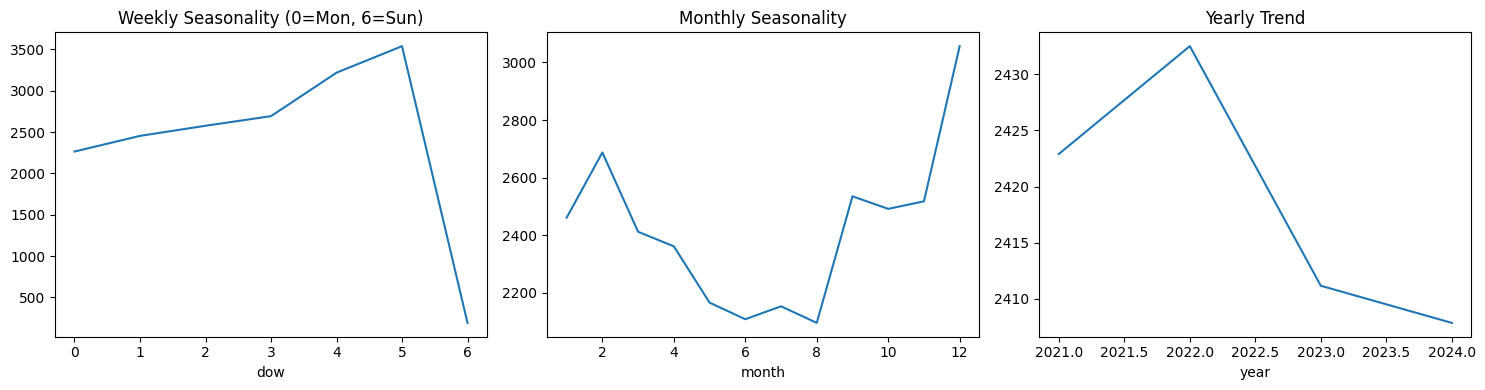

        date  is_weekend  season  days_to_holiday
0 2021-01-01       False       1                0
1 2021-01-01       False       1                0
2 2021-01-01       False       1                0
3 2021-01-01       False       1                0
4 2021-01-01       False       1                0


In [27]:
# Convert to datetime
df_sales['date'] = pd.to_datetime(df_sales['date'])
holidays = pd.to_datetime(df_holidays['date']).sort_values().unique()

# 1. Basic Time Features
df_sales['dow'] = df_sales['date'].dt.dayofweek
df_sales['month'] = df_sales['date'].dt.month
df_sales['quarter'] = df_sales['date'].dt.quarter
df_sales['year'] = df_sales['date'].dt.year
df_sales['is_weekend'] = df_sales['dow'] >= 5

# 2. Season (1:Winter, 2:Spring, 3:Summer, 4:Autumn)
season_map = {12:1, 1:1, 2:1, 3:2, 4:2, 5:2, 6:3, 7:3, 8:3, 9:4, 10:4, 11:4}
df_sales['season'] = df_sales['month'].map(season_map)

# 3. Days to/from Nearest Holiday
# Create a timeline dataframe to compute distances once per date (efficient)
timeline = pd.DataFrame({'date': df_sales['date'].sort_values().unique()})
holiday_df = pd.DataFrame({'holiday_date': holidays})

# merge_asof finds the nearest match
merged = pd.merge_asof(timeline, holiday_df, left_on='date', right_on='holiday_date', direction='nearest')
merged['days_to_holiday'] = (merged['date'] - merged['holiday_date']).dt.days.abs()

# Map back to main df
df_sales = df_sales.merge(merged[['date', 'days_to_holiday']], on='date', how='left')

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df_sales.groupby('dow')['sales'].mean().plot(ax=axes[0], title='Weekly Seasonality (0=Mon, 6=Sun)')
df_sales.groupby('month')['sales'].mean().plot(ax=axes[1], title='Monthly Seasonality')
df_sales.groupby('year')['sales'].mean().plot(ax=axes[2], title='Yearly Trend')
plt.tight_layout()
plt.show()

print(df_sales[['date', 'is_weekend', 'season', 'days_to_holiday']].head())

In [29]:
print(df_sales.columns)

Index(['date', 'store_id', 'store_name', 'city', 'store_type', 'category',
       'sales', 'n_transactions', 'is_holiday', 'holiday_name',
       'days_to_holiday_x', 'days_from_holiday', 'is_weekend', 'day_of_week',
       'month', 'year', 'season', 'dow', 'quarter', 'days_to_holiday_y',
       'days_to_holiday'],
      dtype='object')


In [32]:
# 2 (b)

# Updated grouping key
grp = ['store_id', 'category']

# Sort is CRITICAL
df_sales = df_sales.sort_values(grp + ['date'])

# 1. Lag Features
for lag in [1, 7, 28]:
    df_sales[f'sales_lag_{lag}'] = df_sales.groupby(grp)['sales'].shift(lag)

# 2. Rolling Statistics (Mean & Std)
# shift(1) ensures we don't use current day's sales
for w in [7, 28]:
    df_sales[f'roll_mean_{w}'] = df_sales.groupby(grp)['sales'].transform(lambda x: x.shift(1).rolling(w).mean())
    df_sales[f'roll_std_{w}'] = df_sales.groupby(grp)['sales'].transform(lambda x: x.shift(1).rolling(w).std())

# Drop rows with NaNs generated by lags (optional but cleaner for training)
df_sales = df_sales.dropna()

print(df_sales[['date', 'store_id', 'category', 'sales', 'sales_lag_1', 'roll_mean_7']].head())

             date  store_id category    sales  sales_lag_1  roll_mean_7
217603 2023-12-25         1      AGD   656.28      8249.36  5984.247143
217803 2023-12-26         1      AGD   536.47       656.28  6010.727143
219003 2024-01-01         1      AGD   708.26       536.47  5040.598571
220003 2024-01-06         1      AGD   947.36       708.26  5077.621429
227803 2024-02-14         1      AGD  9394.39       947.36  5101.828571


In [33]:
# 2 (c)

# 1. Historical Mean: Category
df_sales['agg_cat_hist'] = df_sales.groupby('category')['sales'].transform(lambda x: x.shift(1).expanding().mean())

# 2. Historical Mean: Store
df_sales['agg_store_hist'] = df_sales.groupby('store_id')['sales'].transform(lambda x: x.shift(1).expanding().mean())

# 3. Historical Mean: Category per Day of Week
df_sales['agg_cat_dow'] = df_sales.groupby(['category', 'dow'])['sales'].transform(lambda x: x.shift(1).expanding().mean())

# 4. Relative Performance (Sales vs Historical Category Mean)
# (Original request: "Percentile product vs category" is impossible without product_id hierarchy)
df_sales['cat_performance'] = df_sales['sales'] / (df_sales['agg_cat_hist'] + 1e-6)

# Cleanup NaNs from history start
df_sales = df_sales.dropna()

print(df_sales[['date', 'sales', 'agg_cat_hist', 'agg_store_hist', 'agg_cat_dow']].tail())

             date    sales  agg_cat_hist  agg_store_hist  agg_cat_dow
285799 2024-11-29  1139.33    518.692326      657.934506  1124.514583
286399 2024-12-02   511.99    521.565648      659.038624   359.133061
287199 2024-12-06   672.12    521.521521      658.702128  1124.816939
290999 2024-12-25    52.07    522.212339      658.732763   516.822069
291199 2024-12-26    64.04    520.065571      657.350843   124.788621


In [38]:
# 2 (d)

# 0. Prep: Encode category to numbers & Time-based Split
df_sales['cat_code'] = LabelEncoder().fit_transform(df_sales['category'])
split_date = df_sales['date'].max() - pd.Timedelta(days=30) # Last 30 days as test

train = df_sales[df_sales['date'] < split_date]
test = df_sales[df_sales['date'] >= split_date]

# 1. Define Feature Sets
feats_raw = ['store_id', 'cat_code', 'year', 'month', 'dow', 'is_weekend']
feats_eng = feats_raw + [c for c in df_sales.columns if 'lag' in c or 'roll' in c or 'agg' in c or 'days' in c]

# 2. Train & Evaluate
def run_benchmark(features, name):
    model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    model.fit(train[features], train['sales'])
    preds = model.predict(test[features])

    rmse = root_mean_squared_error(test['sales'], preds)
    r2 = r2_score(test['sales'], preds)
    mae = mean_absolute_error(test['sales'], preds)

    print(f"--- {name} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"R2:   {r2:.4f}") # Max 1.0
    return model

print("--- BENCHMARK ---")
model_raw = run_benchmark(feats_raw, "Baseline (Raw)")
model_eng = run_benchmark(feats_eng, "With Engineering")

# 3. Feature Importance
imps = pd.Series(model_eng.feature_importances_, index=feats_eng).sort_values(ascending=False)
print("\n--- TOP 5 FEATURES ---")
print(imps.head(5))

--- BENCHMARK ---
--- Baseline (Raw) ---
RMSE: 5726.25
MAE:  2946.60
R2:   -0.2791
--- With Engineering ---
RMSE: 5103.34
MAE:  2292.30
R2:   -0.0160

--- TOP 5 FEATURES ---
sales_lag_7          0.390018
days_from_holiday    0.341286
roll_mean_28         0.093250
roll_std_28          0.084148
agg_cat_dow          0.024804
dtype: float64
